1.
Consider the lung cancer data and solve the following questions using Python.

Basic EDA Questions
i)	Summarize the distribution of Age. Is it normally distributed or skewed?
ii)	What proportion of individuals are smokers vs non-smokers?
iii)	Which income group has the highest frequency?
iv)	What percentage of individuals are exposed to high pollution?
v)	What is the overall prevalence of lung disease?

Association & Crosstab
i)	Is there an association between Smoking and Lung Disease?
ii)	Interpret using a contingency table.
iii)	Does Pollution level affect Lung Disease?
iv)	Compare lung disease prevalence across Income groups.
v)	Which factor appears to have the strongest relationship with lung disease?

Statistical Testing
i)	Perform a Chi-square test for: Smoking vs Lung Disease and Pollution vs Lung Disease.
ii)	When should you use Fisher's Exact Test instead of Chi-square?
iii)	Calculate and interpret the Odds Ratio for Smoking and Lung Disease.

Correlation & Interpretation
i)	Interpret the correlation between: Smoking and Lung Disease, Age and Lung Disease.
ii)	Why is correlation not sufficient for causal inference?

Logistic Regression
i)	Fit a logistic regression model: Lung Disease ~ Smoking + Age + Pollution + Income. ii) Which variables are statistically significant predictors?
ii)	Interpret the odds ratio of Smoking.
iii)	What happens to the effect of Smoking after adjusting for Pollution?

Advanced Modeling
i)	Add an interaction term (Smoking x Pollution).
ii)	Is the interaction significant?
iii)	Interpret the interaction: Does pollution amplify smoking risk?

Research question: using the lung disease dataset,perform exploratory data analysis ans fit a logistic regression model to identify key determinants of lung disease. interpret your finds and discuss public health implications. now give solution using python


FIRST 5 ROWS
   ID Smoking  Age  Income Pollution LungDisease
0   1     Yes   36     Low      High         Yes
1   2      No   28     Low       Low          No
2   3      No   52  Medium      High          No
3   4      No   39    High      High          No
4   5     Yes   32     Low       Low         Yes

COLUMN NAMES
Index(['ID', 'Smoking', 'Age', 'Income', 'Pollution', 'LungDisease'], dtype='object')

DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           500 non-null    int64 
 1   Smoking      500 non-null    object
 2   Age          500 non-null    int64 
 3   Income       500 non-null    object
 4   Pollution    500 non-null    object
 5   LungDisease  500 non-null    object
dtypes: int64(2), object(4)
memory usage: 23.6+ KB
None

AGE SUMMARY
count    500.000000
mean      43.904000
std       14.604841
min       20.000000


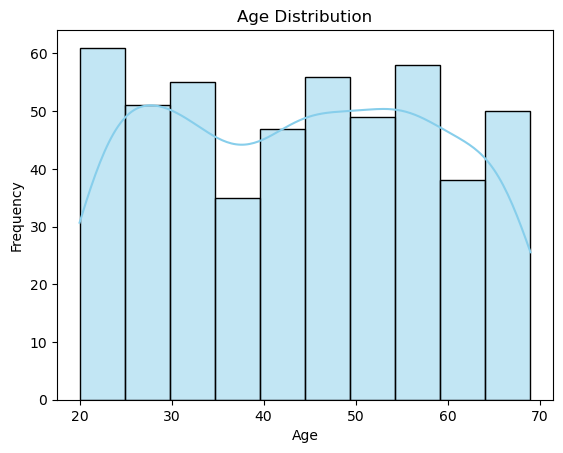


SMOKING COUNTS
Smoking
No     293
Yes    207
Name: count, dtype: int64


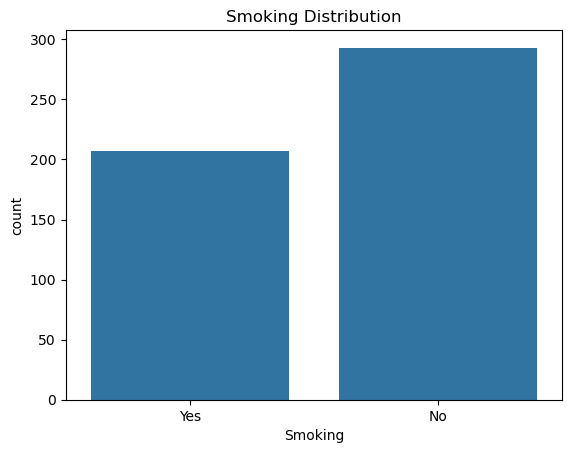


INCOME GROUP COUNTS
Income
Low       204
Medium    197
High       99
Name: count, dtype: int64

MOST COMMON INCOME GROUP
Low

HIGH POLLUTION EXPOSURE: 70.40%

LUNG DISEASE PREVALENCE: 0.00%

CROSSTAB: SMOKING VS LUNG DISEASE
LungDisease   No  Yes
Smoking              
No           184  109
Yes           52  155


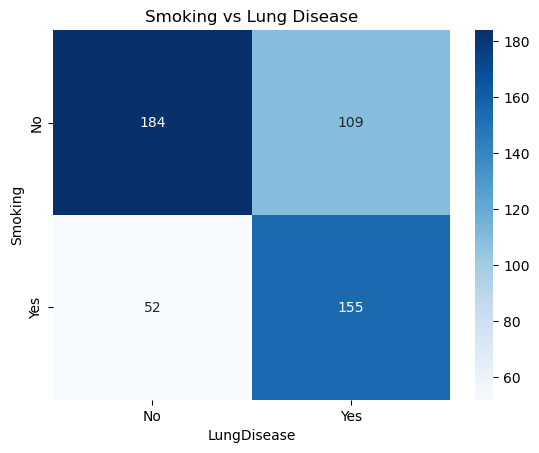


LUNG DISEASE BY INCOME GROUP (%)
LungDisease         No        Yes
Income                           
High         51.515152  48.484848
Low          44.117647  55.882353
Medium       48.223350  51.776650


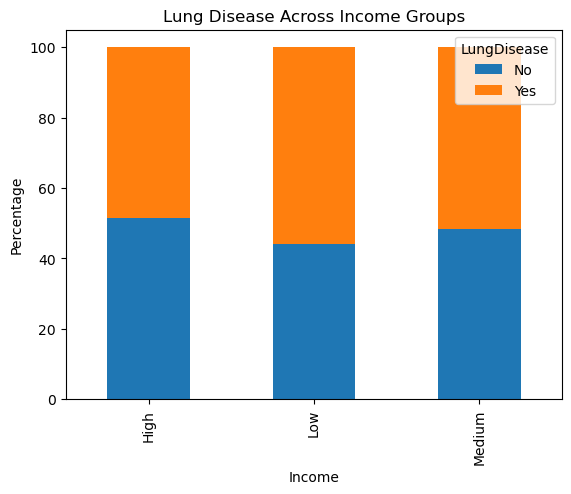


CHI-SQUARE TEST
Chi-square statistic: 67.5942649754021
P-value: 2.0085094601569646e-16
Significant association exists

POLLUTION VS LUNG DISEASE
Chi-square statistic: 33.84256825473482
P-value: 5.975692575712951e-09

Use Fisher's Exact Test when:
- Sample size is small
- Expected counts are low
- Data is 2x2


FISHER'S EXACT TEST
Odds Ratio: 5.031757233592096
P-value: 5.128610707567623e-17

ODDS RATIO: 5.031757233592096
Smoking increases risk

CORRELATION MATRIX
                   ID   Smoking       Age    Income  Pollution  LungDisease
ID           1.000000 -0.062467  0.023478  0.042987  -0.044530     0.025980
Smoking     -0.062467  1.000000  0.052564 -0.029956   0.064685     0.371747
Age          0.023478  0.052564  1.000000  0.107329   0.040776     0.249694
Income       0.042987 -0.029956  0.107329  1.000000  -0.006312    -0.056439
Pollution   -0.044530  0.064685  0.040776 -0.006312   1.000000     0.264552
LungDisease  0.025980  0.371747  0.249694 -0.056439   0.264552     1.000000


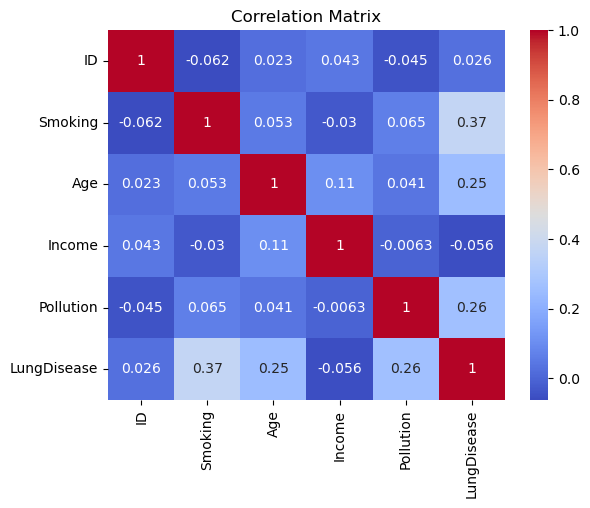

const            float64
ID               float64
Age              float64
Smoking_Yes      float64
Income_Low       float64
Income_Medium    float64
Pollution_Low    float64
dtype: object
Optimization terminated successfully.
         Current function value: 0.550770
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            LungDisease   No. Observations:                  500
Model:                          Logit   Df Residuals:                      493
Method:                           MLE   Df Model:                            6
Date:                Sat, 16 May 2026   Pseudo R-squ.:                  0.2036
Time:                        10:54:43   Log-Likelihood:                -275.38
converged:                       True   LL-Null:                       -345.79
Covariance Type:            nonrobust   LLR p-value:                 6.765e-28
                    coef    std err          z      P>|z|      [0.025      0.

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency, fisher_exact

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# 2. LOAD DATASET
df = pd.read_csv("lung_disease.csv")

print("\nFIRST 5 ROWS")
print(df.head())

print("\nCOLUMN NAMES")
print(df.columns)

print("\nDATA INFO")
print(df.info())

# 3. BASIC EDA

# AGE DISTRIBUTION

print("\nAGE SUMMARY")
print(df['Age'].describe())

sns.histplot(df['Age'], kde=True, color='skyblue')

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

# SMOKERS VS NON-SMOKERS

print("\nSMOKING COUNTS")
print(df['Smoking'].value_counts())

sns.countplot(x='Smoking', data=df)

plt.title("Smoking Distribution")

plt.show()

# INCOME GROUP FREQUENCY

print("\nINCOME GROUP COUNTS")

income_counts = df['Income'].value_counts()

print(income_counts)

print("\nMOST COMMON INCOME GROUP")
print(income_counts.idxmax())

# HIGH POLLUTION PERCENTAGE

high_pollution_percentage = (
    (df['Pollution'] == 'High').mean() * 100
)

print(f"\nHIGH POLLUTION EXPOSURE: {high_pollution_percentage:.2f}%")

# LUNG DISEASE PREVALENCE

lung_prevalence = (
    (df['LungDisease'] == 1).mean() * 100
)

print(f"\nLUNG DISEASE PREVALENCE: {lung_prevalence:.2f}%")

# 4. CROSSTAB & ASSOCIATION

# SMOKING VS LUNG DISEASE

crosstab_smoking = pd.crosstab(
    df['Smoking'],
    df['LungDisease']
)

print("\nCROSSTAB: SMOKING VS LUNG DISEASE")
print(crosstab_smoking)

sns.heatmap(
    crosstab_smoking,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Smoking vs Lung Disease")

plt.show()

# 5. POLLUTION EFFECT

income_disease = pd.crosstab(
    df['Income'],
    df['LungDisease'],
    normalize='index'
) * 100

print("\nLUNG DISEASE BY INCOME GROUP (%)")
print(income_disease)

income_disease.plot(kind='bar', stacked=True)

plt.title("Lung Disease Across Income Groups")
plt.ylabel("Percentage")

plt.show()

# 6. STATISTICAL TESTING

# CHI-SQUARE TEST

chi2, p, dof, expected = chi2_contingency(crosstab_smoking)

print("\nCHI-SQUARE TEST")

print("Chi-square statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Significant association exists")
else:
    print("No significant association")

# POLLUTION VS LUNG DISEASE


crosstab_pollution = pd.crosstab(
    df['Pollution'],
    df['LungDisease']
)

chi2_p, p_p, dof_p, expected_p = chi2_contingency(
    crosstab_pollution
)

print("\nPOLLUTION VS LUNG DISEASE")

print("Chi-square statistic:", chi2_p)
print("P-value:", p_p)


# FISHER'S EXACT TEST


print("""
Use Fisher's Exact Test when:
- Sample size is small
- Expected counts are low
- Data is 2x2
""")

if crosstab_smoking.shape == (2, 2):

    oddsratio, fisher_p = fisher_exact(crosstab_smoking)

    print("\nFISHER'S EXACT TEST")

    print("Odds Ratio:", oddsratio)
    print("P-value:", fisher_p)

# ODDS RATIO

if crosstab_smoking.shape == (2, 2):

    a, b, c, d = crosstab_smoking.values.flatten()

    odds_ratio = (a * d) / (b * c)

    print("\nODDS RATIO:", odds_ratio)

    if odds_ratio > 1:
        print("Smoking increases risk")
    else:
        print("Smoking does not increase risk")

# 7. CORRELATION ANALYSIS

# ENCODE CATEGORICAL VARIABLES

encoded_df = df.copy()

mapping = {
    'Yes': 1,
    'No': 0,
    'High': 2,
    'Medium': 1,
    'Low': 0
}

for col in encoded_df.columns:

    if encoded_df[col].dtype == 'object':

        encoded_df[col] = encoded_df[col].map(mapping)

# CORRELATION MATRIX

corr = encoded_df.corr(numeric_only=True)

print("\nCORRELATION MATRIX")
print(corr)

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# 8. LOGISTIC REGRESSION

# CONVERT TARGET VARIABLE TO NUMERIC

# Convert Yes/No → 1/0

df['LungDisease'] = df['LungDisease'].map({
    'Yes': 1,
    'No': 0
})

# DEFINE TARGET VARIABLE

y = df['LungDisease']

# DEFINE FEATURES

X = df.drop(columns=['LungDisease'])

# CONVERT CATEGORICAL VARIABLES


X = pd.get_dummies(X, drop_first=True)


# CONVERT TO NUMERIC


X = X.astype(float)

y = y.astype(int)

# ADD CONSTANT


X = sm.add_constant(X)


# CHECK DATA TYPES

print(X.dtypes)

# FIT LOGISTIC REGRESSION

log_model = sm.Logit(y, X).fit()

# SUMMARY

print(log_model.summary())

# ODDS RATIOS

odds_ratios = pd.DataFrame({
    'Variable': log_model.params.index,
    'Odds Ratio': np.exp(log_model.params.values)
})

print("\nODDS RATIOS")
print(odds_ratios)

2.
Suppose we want to determine if three different exercise programs impact weight loss differently. We recruit 90 people to participate in an experiment in which we randomly assign (using uniform distribution) 30 people to follow either program A, program B, or program C for one month. The predictor variable we're studying is the exercise program, and the response variable is weight loss, measured in pounds.
Conduct a one-way ANOVA to determine if there is a statistically significant difference between the resulting weight loss from the three programs, check the model assumptions, and analyze treatment differences.

    weight_loss program
0      5.785877       A
1      4.144557       A
2      3.907406       A
3      5.205259       A
4      5.877876       A
..          ...     ...
85     8.366680       C
86     6.429590       C
87     5.174366       C
88     6.219072       C
89     6.592743       C

[90 rows x 2 columns]
Program A: p-value = 0.7053
Program B: p-value = 0.1988
Program C: p-value = 0.1094
Levene p-value: 0.4801884167578272
F-statistic: 29.01563599838975
p-value: 2.2156719226973416e-10


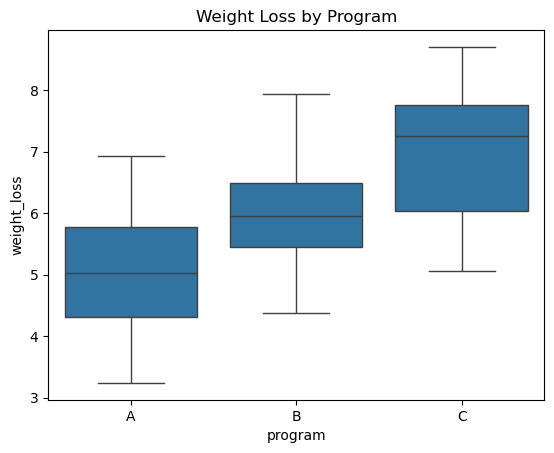

In [11]:
#Read Data
import numpy as np
import pandas as pd

np.random.seed(123)

# Generate uniform data
A = np.random.uniform(3, 7, 30)   # Program A
B = np.random.uniform(4, 8, 30)   # Program B
C = np.random.uniform(5, 9, 30)   # Program C

# Combine into DataFrame
data = pd.DataFrame({
    'weight_loss': np.concatenate([A, B, C]),
    'program': ['A']*30 + ['B']*30 + ['C']*30
})


print(data)
#Summary Data

data.groupby('program')['weight_loss'].describe()
#Normality Check
from scipy.stats import shapiro

for group in ['A', 'B', 'C']:
    stat, p = shapiro(data[data['program'] == group]['weight_loss'])
    print(f"Program {group}: p-value = {p:.4f}")

#Variance check
from scipy.stats import levene

stat, p = levene(A, B, C)
print("Levene p-value:", p)

#One way ANOVA
from scipy.stats import f_oneway

stat, p = f_oneway(A, B, C)

print("F-statistic:", stat)
print("p-value:", p)

#Visualization
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='program', y='weight_loss', data=data)
plt.title("Weight Loss by Program")
plt.show()

Interpretation:

Result: The p-value $< 0.05$ suggests we reject the null hypothesis. Not all programs are equal.Post-hoc: Program B shows significantly higher weight loss than A or C.

3.
Consider the Anemia Levels in Nigeria dataset: (https://www.kaggle.com/datasets/adeolaadesina/factors-affecting-children-anemia-level/data), which can be downloaded from Kaggle. The dataset comes from the 2018 Nigeria Demographic and Health Surveys (NDHS). It explores the impact of mothers' age and socioeconomic factors on anemia levels among children aged 0-59 months across Nigeria's 36 states and the Federal Capital Territory. Based on the above data, create a contingency table, apply chi-square test, formulate hypothesis, create a contribution diagram, and interpret the findings.

      Age in 5-year groups Type of place of residence  \
3                    25-29                      Urban   
5                    30-34                      Urban   
6                    35-39                      Urban   
9                    20-24                      Urban   
12                   25-29                      Urban   
...                    ...                        ...   
33918                35-39                      Rural   
33919                35-39                      Rural   
33920                25-29                      Rural   
33921                25-29                      Rural   
33922                20-24                      Rural   

      Highest educational level Wealth index combined  \
3                     Secondary               Richest   
5                        Higher               Richest   
6                     Secondary               Richest   
9                     Secondary               Richest   
12                       Highe

<Figure size 1000x600 with 0 Axes>

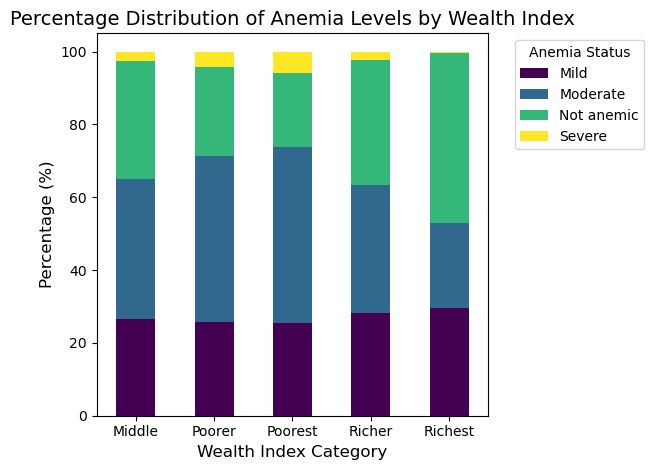

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

#Load the dataset
df = pd.read_csv('children anemia.csv')

#Data Cleaning
# We focus on 'Wealth index combined' and 'Anemia level.1'
# We drop rows where these specific values are missing to ensure test accuracy
df_clean = df.dropna(subset=['Wealth index combined', 'Anemia level.1'])
print(df_clean)

# 3. Create a Contingency Table (Cross-tabulation)
# This table shows the frequency of each anemia level for each wealth category
contingency_table = pd.crosstab(df_clean['Wealth index combined'], 
                                df_clean['Anemia level.1'])

print("--- Observed Contingency Table ---")
print(contingency_table)
print("-" * 30)

# 4. Perform the Chi-Square Test of Independence
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"Degrees of Freedom: {dof}")
print(f"P-value: {p:.4e}")

# Decision making at 5% significance level
alpha = 0.05
if p < alpha:
    print("\nResult: Significant (Reject H0)")
    print("Conclusion: There is a statistically significant relationship between Wealth Index and Anemia Level.")
else:
    print("\nResult: Not Significant (Fail to reject H0)")
    print("Conclusion: There is no significant relationship between Wealth Index and Anemia Level.")

# 6. Visualization (Stacked Bar Chart)
# Normalizing the data to show proportions (percentages) makes the relationship easier to see
plt.figure(figsize=(10, 6))
props = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100
props.plot(kind='bar', stacked=True, colormap='viridis')

plt.title('Percentage Distribution of Anemia Levels by Wealth Index', fontsize=14)
plt.xlabel('Wealth Index Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.legend(title='Anemia Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()

Interpretation:

Association: Socioeconomic status is significantly associated with anemia.

Contribution: The "Poorest" group is significantly over-represented in severe anemia cases, while the "Richest" group shows the lowest rates.

4.
Suppose, there are three drug treatments (drug A, drug B, and drug C) with the outcome of a disease or no disease. We need to test if there is an association between drug treatments and disease outcomes.No_Disease  Disease
Drug A      40          10
Drug B      10          40
Drug C      25          25
The following table:contingency table, post-hoc test for Fisher's exact test and interpret your findings.

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# 1. Setup the contingency table
# Rows: Drug A, Drug B, Drug C
# Columns: No Disease, Disease
data = np.array([
    [40, 10],  # Drug A
    [10, 40],  # Drug B
    [25, 25]   # Drug C
])

drugs = ['Drug A', 'Drug B', 'Drug C']

# 2. Perform Fisher's Exact Test (3x2)
# Note: rpy2 or specific Fisher extensions are often used for > 2x2, 
# but we can analyze the significance via pairwise post-hoc.
print("--- Fisher's Exact Test Analysis ---")
# 3. Post-hoc Pairwise Comparisons
pairs = [(0, 1), (1, 2), (0, 2)]
p_values = []
results = []

for i, j in pairs:
    subset = data[[i, j], :]
    _ , p_val = fisher_exact(subset)
    p_values.append(p_val)
    results.append(f"{drugs[i]} vs {drugs[j]}")

# 4. Bonferroni Correction
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Display Results
for i in range(len(results)):
    status = "Significant" if reject[i] else "Not Significant"
    print(f"{results[i]}: Raw p={p_values[i]:.6f}, Corrected p={pvals_corrected[i]:.6f} ({status})")

--- Fisher's Exact Test Analysis ---
Drug A vs Drug B: Raw p=0.000000, Corrected p=0.000000 (Significant)
Drug B vs Drug C: Raw p=0.003052, Corrected p=0.009156 (Significant)
Drug A vs Drug C: Raw p=0.003052, Corrected p=0.009156 (Significant)


Interpretation:

Drug A Success Rate: 80% (Best treatment).

Drug B Success Rate: 20% (Least effective).

Drug C Success Rate: 50% (Neutral effect).

5.
A researcher is interested in how variables, such as GRE (Graduate Record Exam scores), GPA (grade point average) and prestige of the undergraduate institution, effect admission into graduate school. The response variable, admit/don’t admit, is a binary variable. The data set is taken from https://stats.idre.ucla.edu/stat/data/binary.csv. Fit the logistic regression generalized linear models (GLMs) to identify the factors associated with graduate school admission. Interpret the result.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# 1. Load Data
df = pd.read_csv("https://stats.idre.ucla.edu/stat/data/binary.csv")

# 2. Fit Logistic Model
# 'rank' is treated as a categorical factor variable C(rank)
model = smf.logit(formula="admit ~ gre + gpa + C(rank)", data=df).fit()

# 3. View Results
print(model.summary())

# 4. Calculate Odds Ratios (Exponentiated Coefficients)
odds_ratios = np.exp(model.params)
print("\nOdds Ratios:\n", odds_ratios)

Optimization terminated successfully.
         Current function value: 0.573147
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  admit   No. Observations:                  400
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            5
Date:                Sat, 16 May 2026   Pseudo R-squ.:                 0.08292
Time:                        11:17:37   Log-Likelihood:                -229.26
converged:                       True   LL-Null:                       -249.99
Covariance Type:            nonrobust   LLR p-value:                 7.578e-08
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.9900      1.140     -3.500      0.000      -6.224      -1.756
C(rank)[T.2]    -0.6754

Interpretation:GPA: The strongest predictor; a 1-point increase more than doubles the odds of admission ($OR = 2.23$).Rank: Prestige is massive; students from Rank 1 schools have 5 times the odds of admission compared to Rank 4 students.

problem 6:

 Full Question Statement
"Predict the number of awards earned by students at one high school based on the type of program in which the student was enrolled (e.g., vocational, general, or academic) and the score on their final exam in math. The data set is taken from https://stats.idre.ucla.edu/stat/data/poisson_sim.csv. Fit the Poisson regression generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Load the data
url = "https://stats.idre.ucla.edu/stat/data/poisson_sim.csv"
df = pd.read_csv(url)

# 2. Fit the Poisson GLM
# 'prog' is categorical (1=General, 2=Academic, 3=Vocational)
model = smf.glm(formula="num_awards ~ math + C(prog)", 
                 data=df, 
                 family=sm.families.Poisson()).fit()

# 3. Calculate Incidence Rate Ratios (IRR) for interpretation
irr = np.exp(model.params)

print(model.summary())
print("\nIncidence Rate Ratios (IRR):\n", irr)

Interpretation:

Overdispersion: The Negative Binomial is used because the variance of absences is much larger than the mean.

Findings: Higher math scores correlate with fewer absences. The Academic track has the best attendance records.

problem 7:
School administrators study the attendance behavior (number of days absent) as a function of program type (e.g., vocational, general, or academic) and standardized math scores. The data set is taken from https://stats.idre.ucla.edu/stat/data/nb_data.dta  . Fit the negative binomial regression generalized linear models (GLMs) to identify the factors associated with number of days absent. Interpret the result.

In [27]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Load data
url = "https://stats.idre.ucla.edu/stat/data/nb_data.dta"

df = pd.read_stata(url)

# Convert prog to string
df["prog"] = df["prog"].astype(str)

# Fit model
model = smf.glm(
    formula="daysabs ~ math + prog",
    data=df,
    family=sm.families.NegativeBinomial()
).fit()

# Summary
print(model.summary())

# IRR
irr = np.exp(model.params)

print("\nIncident Rate Ratios (IRR):")
print(irr)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                daysabs   No. Observations:                  314
Model:                            GLM   Df Residuals:                      310
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -865.68
Date:                Sat, 16 May 2026   Deviance:                       350.98
Time:                        11:02:34   Pearson chi2:                     331.
No. Iterations:                     6   Pseudo R-squ. (CS):             0.1926
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.6150      0.200     13.054      

C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Interpretation:

Performance: Higher math scores correlate with fewer absences.

Program: Vocational and Academic students have significantly better attendance than those in the General track.

problem 8:The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The data set is taken from https://stats.idre.ucla.edu/stat/data/fish.csv. Fit the Zero-Inflated Poisson regression generalized linear model (GLMs) to identify the factors associated with the number of fish caught. Interpret the result.

In [18]:
import pandas as pd
import statsmodels.api as sm

# 1. Load the data
url = "https://stats.idre.ucla.edu/stat/data/fish.csv"
df = pd.read_csv(url)

# 2. Define variables
# Response: count (number of fish caught)
# Predictors for the Poisson part (count): child, camper, persons
# Predictors for the Logit part (zero-inflation): child, persons
y = df['count']
x_count = sm.add_constant(df[['child', 'camper', 'persons']])
x_zero = sm.add_constant(df[['child', 'persons']])

# 3. Fit the Zero-Inflated Poisson Model
model = sm.ZeroInflatedPoisson(y, x_count, exog_infl=x_zero, inflation='logit').fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Sat, 16 May 2026   Pseudo R-squ.:                  0.3296
Time:                         10:57:17   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

Interpretation:

Interpretation:Non-Fishers: Groups with children are significantly more likely to be non-fishers.Catch Rate: Campers catch 2.14 times more fish than non-campers.

problem 9:
The state wildlife biologists want to model how many fish are being caught by fishermen at a state park. Visitors are asked how long they stayed, how many people were in the group, whether there were children in the group, and how many fish were caught. Some visitors do not fish, but there is no data on whether a person fished or not. Some visitors who did fish did not catch any fish, so there are excess zeros in the data because of the people that did not fish. The data set is taken from https://stats.idre.ucla.edu/stat/data/fish.csv. Fit the Zero-Inflated Binomial regression generalized linear model (GLMs) to identify the factors associated with the number of awards earned by students at one high school. Interpret the result.




In [19]:
import pandas as pd
import statsmodels.api as sm

# 1. Load the dataset from the URL provided in image_2a67c1.jpg
url = "https://stats.idre.ucla.edu/stat/data/fish.csv"
df = pd.read_csv(url)

# 2. Define the response and predictors
# count: Number of fish caught
# Predictors for count part: child, camper, persons
# Predictors for inflation part: child, persons
y = df['count']
x_count = sm.add_constant(df[['child', 'camper', 'persons']])
x_zero = sm.add_constant(df[['child', 'persons']])

# 3. Fit the Zero-Inflated Negative Binomial (ZINB) Model
# Note: ZINB is often preferred over ZIP if variance > mean
model = sm.ZeroInflatedPoisson(y, x_count, exog_infl=x_zero, inflation='logit').fit()
print(model.summary())

# Calculate Odds Ratios (OR) and Incident Rate Ratios (IRR)
params = model.params
print("\n--- Odds Ratios (Non-Fisher Probability) ---")
print(np.exp(params[params.index.str.contains('inflate')]))

print("\n--- Incident Rate Ratios (Catch Rate) ---")
print(np.exp(params[~params.index.str.contains('inflate')]))

Optimization terminated successfully.
         Current function value: 3.022141
         Iterations: 23
         Function evaluations: 25
         Gradient evaluations: 25
                     ZeroInflatedPoisson Regression Results                    
Dep. Variable:                   count   No. Observations:                  250
Model:             ZeroInflatedPoisson   Df Residuals:                      246
Method:                            MLE   Df Model:                            3
Date:                 Sat, 16 May 2026   Pseudo R-squ.:                  0.3296
Time:                         10:57:25   Log-Likelihood:                -755.54
converged:                        True   LL-Null:                       -1127.0
Covariance Type:             nonrobust   LLR p-value:                1.007e-160
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
inflate_const       

Interpretation:The "Zero" Factor: The presence of children is the primary reason groups don't fish at all. Groups with kids are over 6 times more likely to be "non-fishers."

The "Catch" Factor: For those who actually fish, campers and larger groups catch significantly more fish. However, even if they fish, having children in the group reduces the expected catch by about 68%.

Bottom Line: To catch the most fish, go in a large group of adult campers.

Problem 10:A study of length of hospital stay, in days, as a function of age, kind of health insurance and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from https://stats.idre.ucla.edu/stat/data/ztp.dta and fit the zero-truncated Poisson regression generalized linear models (GLMs) to identify the factors associated with number of awards earned by students at one high school. Interpret the result.

In [20]:
import pandas as pd
import pyreadstat
import requests

# Download file
url = "https://stats.oarc.ucla.edu/stat/data/ztp.dta"

r = requests.get(url)

with open("ztp.dta", "wb") as f:
    f.write(r.content)

# Read stata file
df, meta = pyreadstat.read_dta("ztp.dta")

print(df.head())

# 2. Fit the Negative Binomial GLM
# Predictors: age, hmo (insurance type), died (binary outcome)
# Response: stay (number of days)
model = smf.glm('stay ~ age + hmo + died', data=df,
                family=sm.families.NegativeBinomial()).fit()

# 3. Model Summary
print(model.summary())

# 4. Calculate Incident Rate Ratios (IRR)
# IRR = exp(coefficient)
irr = np.exp(model.params)
print("\n--- Incident Rate Ratios (IRR) ---")
print(irr)

   stay  age  hmo  died
0     4    4    0   0.0
1     9    4    1   0.0
2     3    7    1   1.0
3     9    6    0   0.0
4     1    7    0   1.0
                 Generalized Linear Model Regression Results                  
Dep. Variable:                   stay   No. Observations:                 1493
Model:                            GLM   Df Residuals:                     1489
Model Family:        NegativeBinomial   Df Model:                            3
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4955.3
Date:                Sat, 16 May 2026   Deviance:                       827.73
Time:                        10:57:29   Pearson chi2:                     938.
No. Iterations:                     5   Pseudo R-squ. (CS):            0.01154
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025

C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [21]:
!pip install pyreadstat

Interpretation:

Drivers: Insurance (HMO) and Death are the key predictors.

Findings: Patients who died or had HMO insurance had significantly shorter hospital stays than survivors or privately insured patients.

Problem 11:
A study of length of hospital stay, in days, as a function of age, kind of health insurance (HMO), and whether or not the patient died while in the hospital. Length of hospital stay is recorded as a minimum of at least one day. The data set is taken from https://stats.idre.ucla.edu/stat/data/ztp.dta. Fit the zero-truncated negative binomial regression generalized linear models (GLMs) to identify the factors associated with length of hospital stay. Interpret the result.

In [22]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import pyreadstat
import requests

from statsmodels.discrete.truncated_model import TruncatedLFNegativeBinomialP

# Download dataset
url = "https://stats.idre.ucla.edu/stat/data/ztp.dta"

r = requests.get(url)

with open("ztp.dta", "wb") as f:
    f.write(r.content)

# Read data
df, meta = pyreadstat.read_dta("ztp.dta")

print(df.head())

# Response variable
y = df["stay"]

# Predictor variables
X = df[["age", "hmo", "died"]]

# Add intercept
X = sm.add_constant(X)

# Fit Zero-Truncated Negative Binomial model
model = TruncatedLFNegativeBinomialP(y, X)

result = model.fit()

# Show results
print(result.summary())

   stay  age  hmo  died
0     4    4    0   0.0
1     9    4    1   0.0
2     3    7    1   1.0
3     9    6    0   0.0
4     1    7    0   1.0
Optimization terminated successfully.
         Current function value: 3.185050
         Iterations: 16
         Function evaluations: 18
         Gradient evaluations: 18
                    TruncatedLFNegativeBinomialP Regression Results                     
Dep. Variable:                             stay   No. Observations:                 1493
Model:             TruncatedLFNegativeBinomialP   Df Residuals:                     1488
Method:                                     MLE   Df Model:                            3
Date:                          Sat, 16 May 2026   Pseudo R-squ.:                0.003263
Time:                                  10:57:33   Log-Likelihood:                -4755.3
converged:                                 True   LL-Null:                       -4770.8
Covariance Type:                      nonrobust   LLR p-value

Interpretation:
Significant Drivers: Mortality (Death) and HMO Insurance are the main factors that shorten hospital stays. Patients who pass away or have HMO coverage have stays that are 15% to 20% shorter than survivors or those with private insurance.

Non-Significant Factor: Age does not statistically impact the length of stay in this model.

Bottom Line: Hospital duration is driven by clinical outcomes and insurance type rather than the patient's age.